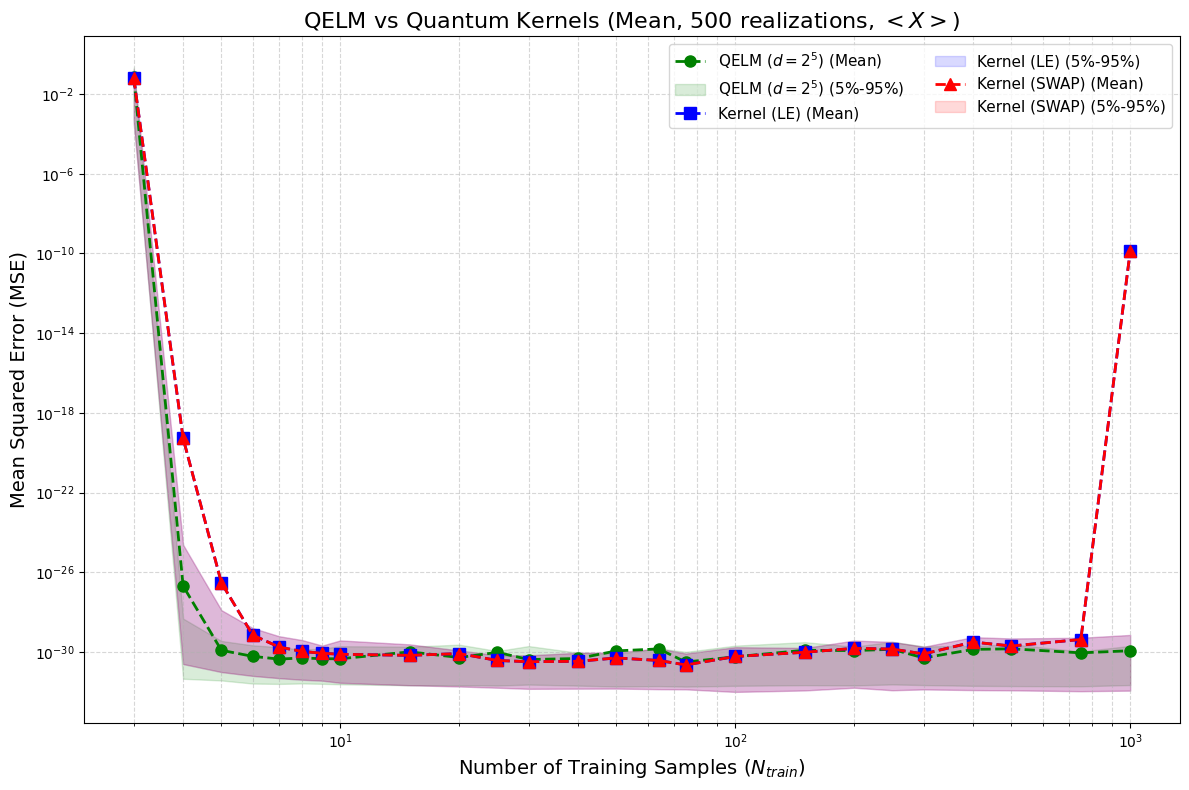

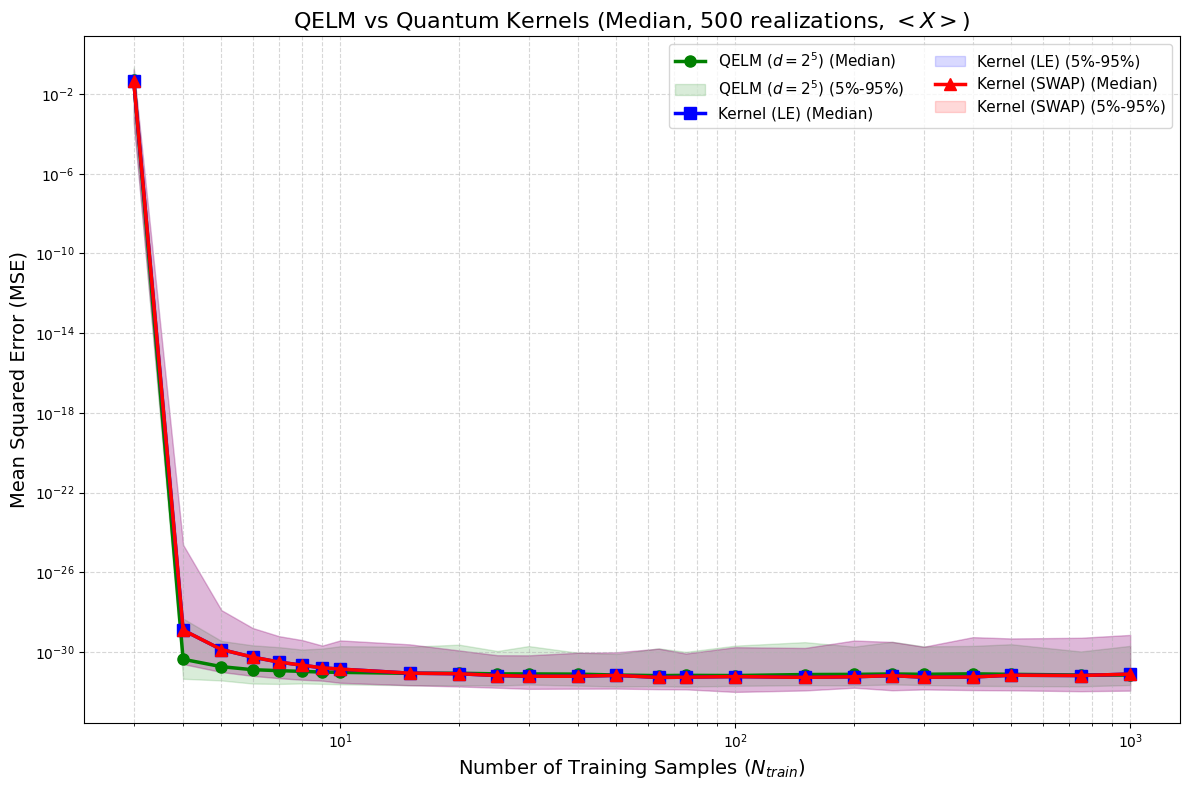

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

filename = "exact_results.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
#print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
#    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")


# ==========================================
# 3. Plotting Setup
# ==========================================
colors = {'QELM': 'green', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^6$)', 'Kernel_LE': 'Kernel (LE)', 'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}


# ==========================================
# IMAGE 1: MEAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Mean plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels (Mean, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()


# ==========================================
# IMAGE 2: MEDIAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Median plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels (Median, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()

# Show both figures at the same time
plt.show()

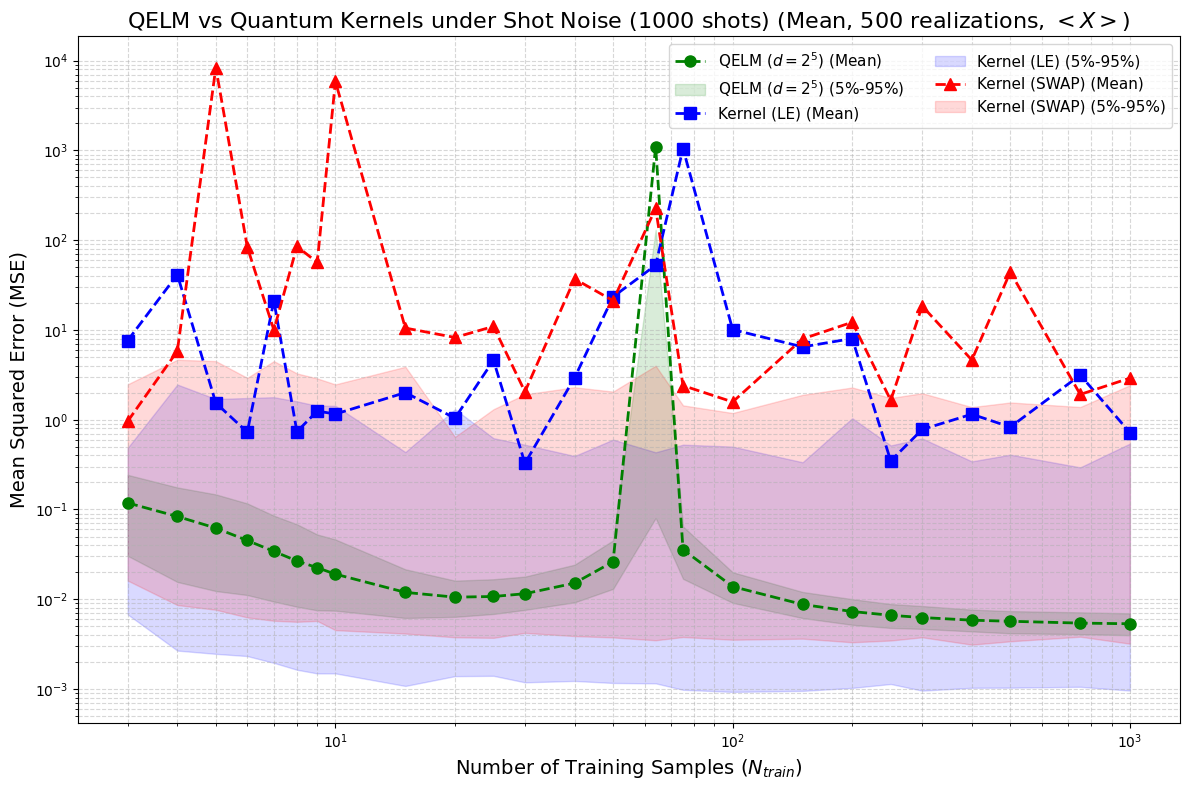

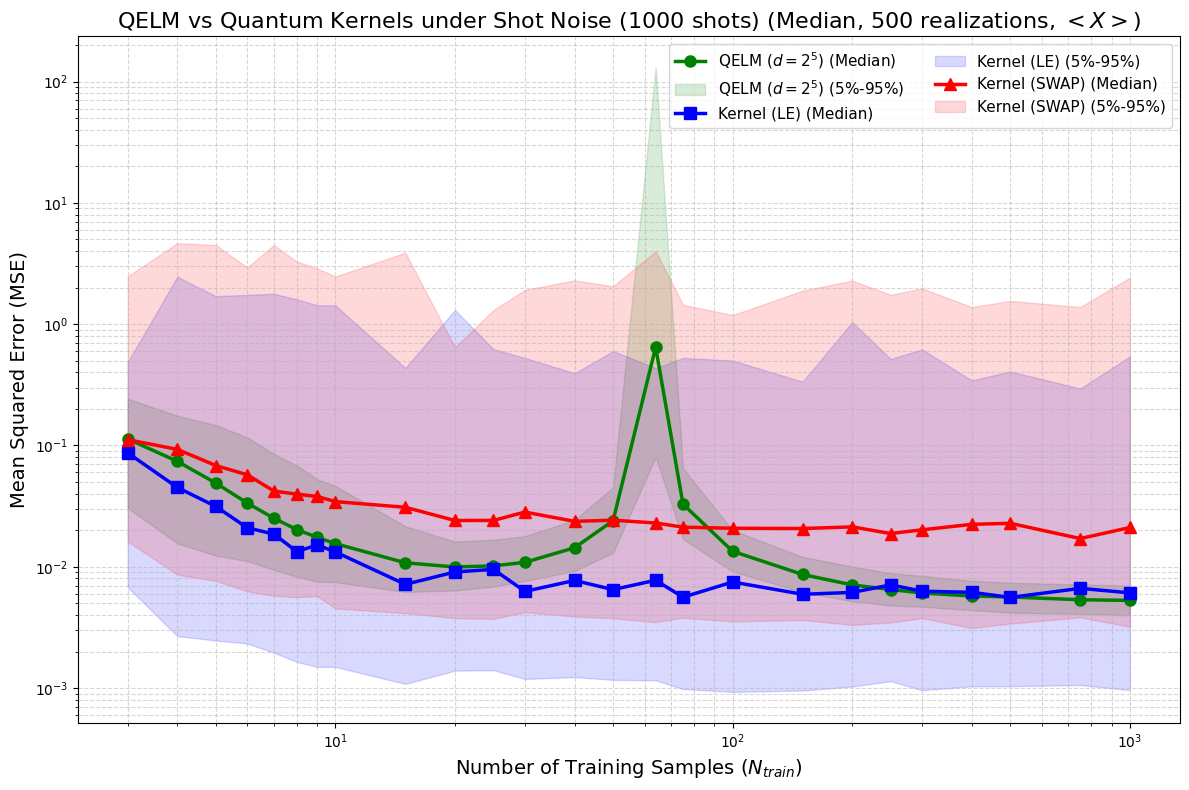

In [ ]:
filename = "1000_shots_results.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
#print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
#    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")


# ==========================================
# 3. Plotting Setup
# ==========================================
colors = {'QELM': 'green', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^6$)', 'Kernel_LE': 'Kernel (LE)', 'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}


# ==========================================
# IMAGE 1: MEAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Mean plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (1000 shots) (Mean, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()


# ==========================================
# IMAGE 2: MEDIAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Median plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (1000 shots) (Median, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()

# Show both figures at the same time
plt.show()

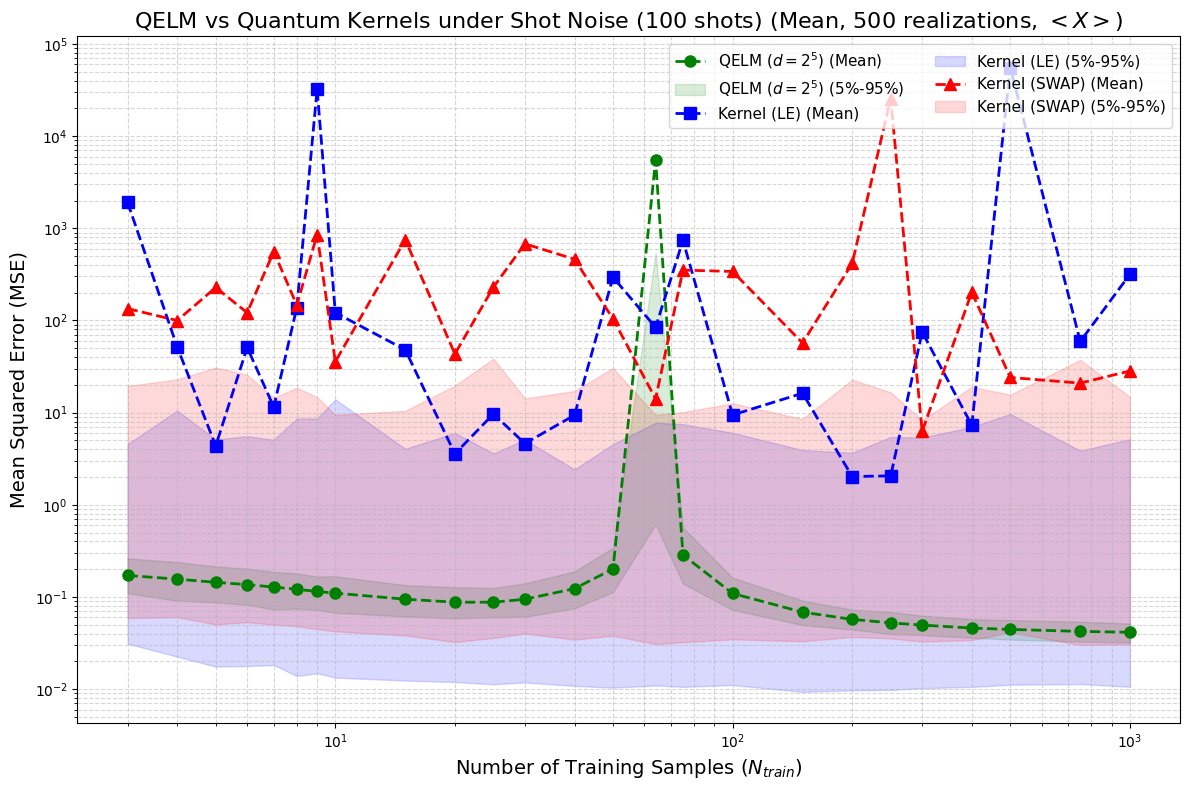

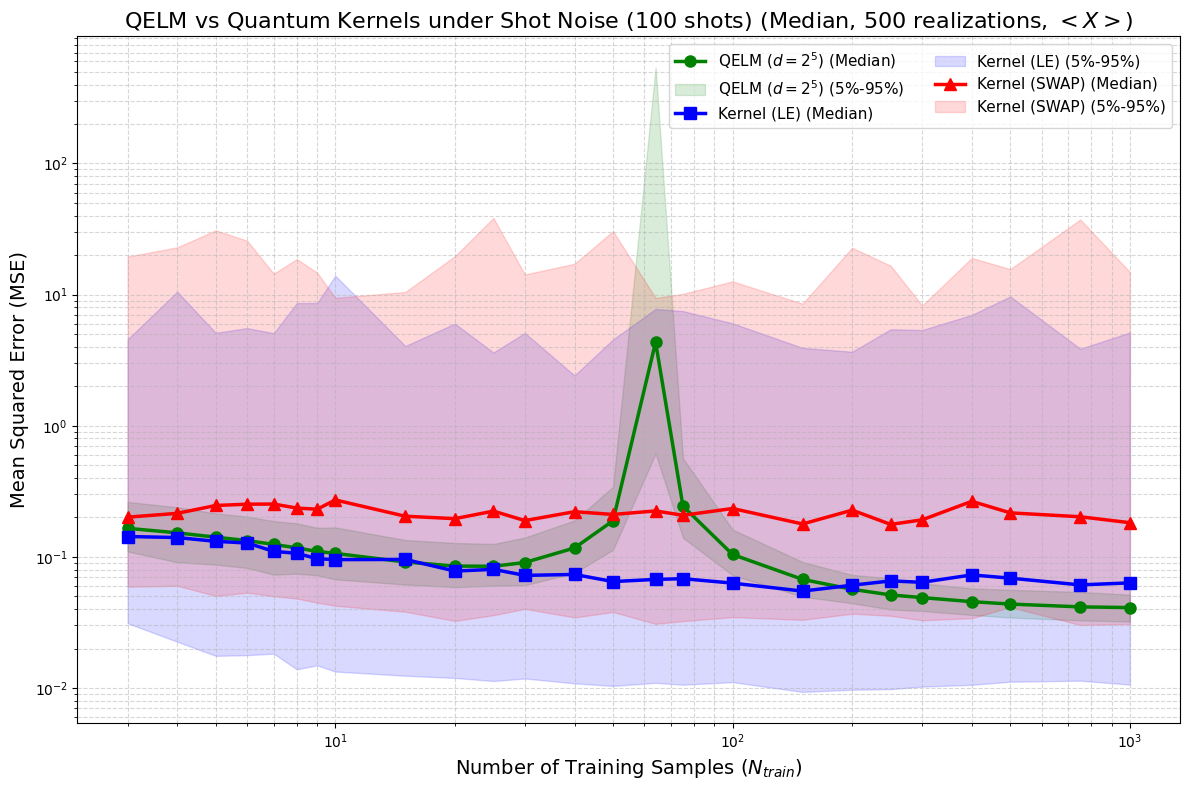

In [ ]:
filename = "100_shots_results.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
#print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
#    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")


# ==========================================
# 3. Plotting Setup
# ==========================================
colors = {'QELM': 'green', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^6$)', 'Kernel_LE': 'Kernel (LE)', 'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}


# ==========================================
# IMAGE 1: MEAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Mean plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (100 shots) (Mean, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()


# ==========================================
# IMAGE 2: MEDIAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Median plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (100 shots) (Median, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()

# Show both figures at the same time
plt.show()

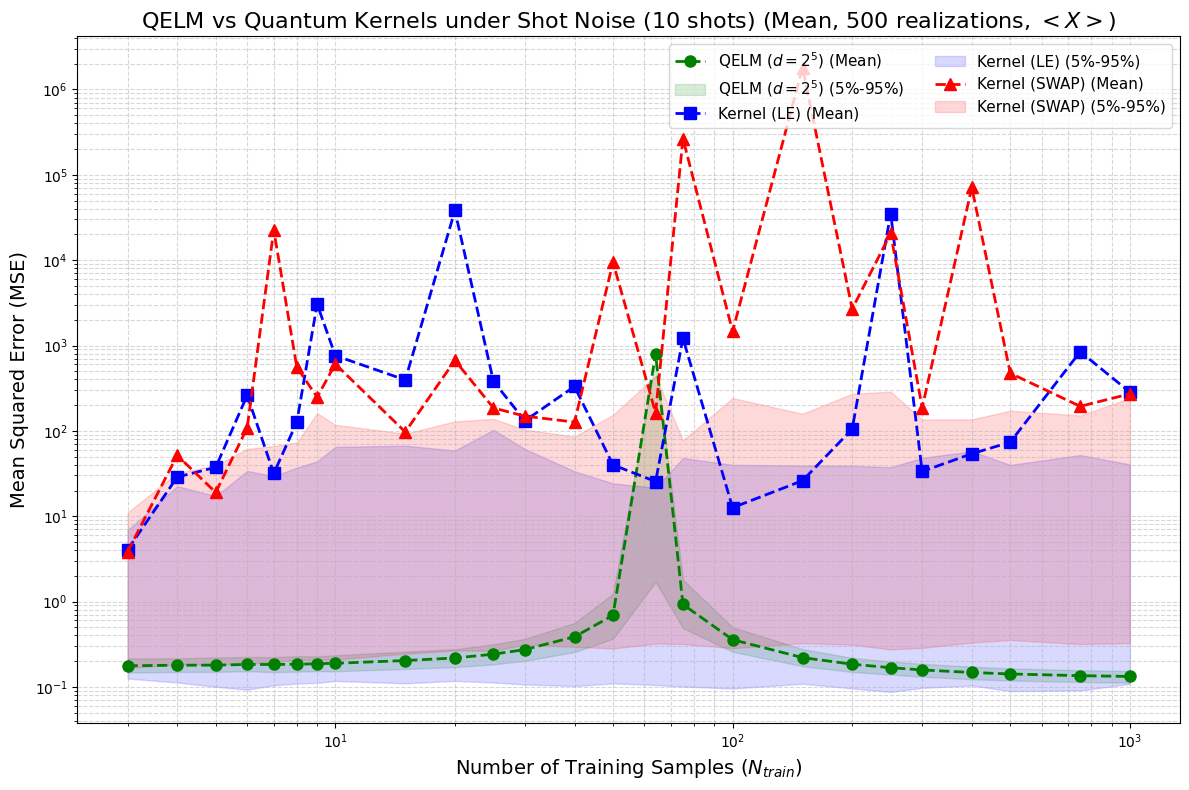

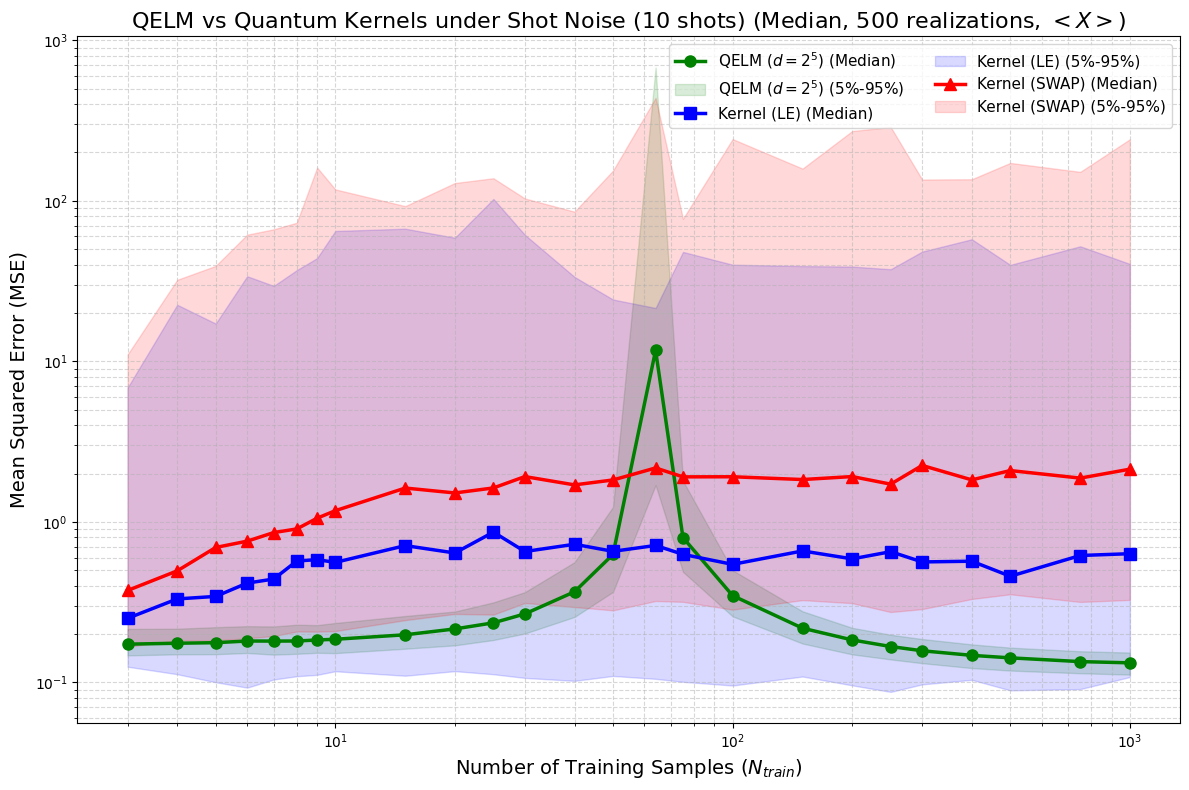

In [ ]:
filename = "10_shots_results.json"

# 1. Load the data
with open(filename, 'r') as f:
    data = json.load(f)

# Extract the N_train values present in the file and sort them numerically
# (We convert them back from strings to integers)
N_train_list = sorted([int(k) for k in data['QELM'].keys()])
N_arr = np.array(N_train_list)

# Storage dictionaries for final plotting
results_mean = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_5 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
quantiles_95 = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

# 2. Compute statistics
#print("\n--- Final Results ---")
for N_train in N_train_list:
    str_N = str(N_train) # JSON keys are strings
    for model in ['QELM', 'Kernel_LE', 'Kernel_SWAP']:
        mse_array = np.array(data[model][str_N])
        
        results_mean[model].append(np.mean(mse_array))
        results_median[model].append(np.median(mse_array))
        quantiles_5[model].append(np.percentile(mse_array, 5))
        quantiles_95[model].append(np.percentile(mse_array, 95))
        
#    print(f"N = {N_train:<4d} | QELM: {results_mean['QELM'][-1]:.4f} | K-LE: {results_mean['Kernel_LE'][-1]:.4f} | K-SW: {results_mean['Kernel_SWAP'][-1]:.4f}")


# ==========================================
# 3. Plotting Setup
# ==========================================
colors = {'QELM': 'green', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^6$)', 'Kernel_LE': 'Kernel (LE)', 'Kernel_SWAP': 'Kernel (SWAP)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}


# ==========================================
# IMAGE 1: MEAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_mean.keys():
    mean_arr = np.array(results_mean[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Mean
    plt.plot(N_arr, mean_arr, label=f'{labels[model]} (Mean)', color=colors[model], 
             marker=markers[model], linestyle='--', linewidth=2.0, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Mean plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (10 shots) (Mean, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()


# ==========================================
# IMAGE 2: MEDIAN PLOT
# ==========================================
plt.figure(figsize=(12, 8))

for model in results_median.keys():
    median_arr = np.array(results_median[model])
    q5_arr = np.array(quantiles_5[model])
    q95_arr = np.array(quantiles_95[model])
    
    # Plot Median
    plt.plot(N_arr, median_arr, label=f'{labels[model]} (Median)', color=colors[model], 
             marker=markers[model], linestyle='-', linewidth=2.5, markersize=8)
    
    # Fill between quantiles
    plt.fill_between(N_arr, q5_arr, q95_arr, color=colors[model], alpha=0.15, label=f'{labels[model]} (5%-95%)') 

# Formatting for Median plot
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title('QELM vs Quantum Kernels under Shot Noise (10 shots) (Median, 500 realizations, $<X>$)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, ncol=2, loc='upper right') 
plt.tight_layout()

# Show both figures at the same time
plt.show()